S&P 500 plot generated successfully.


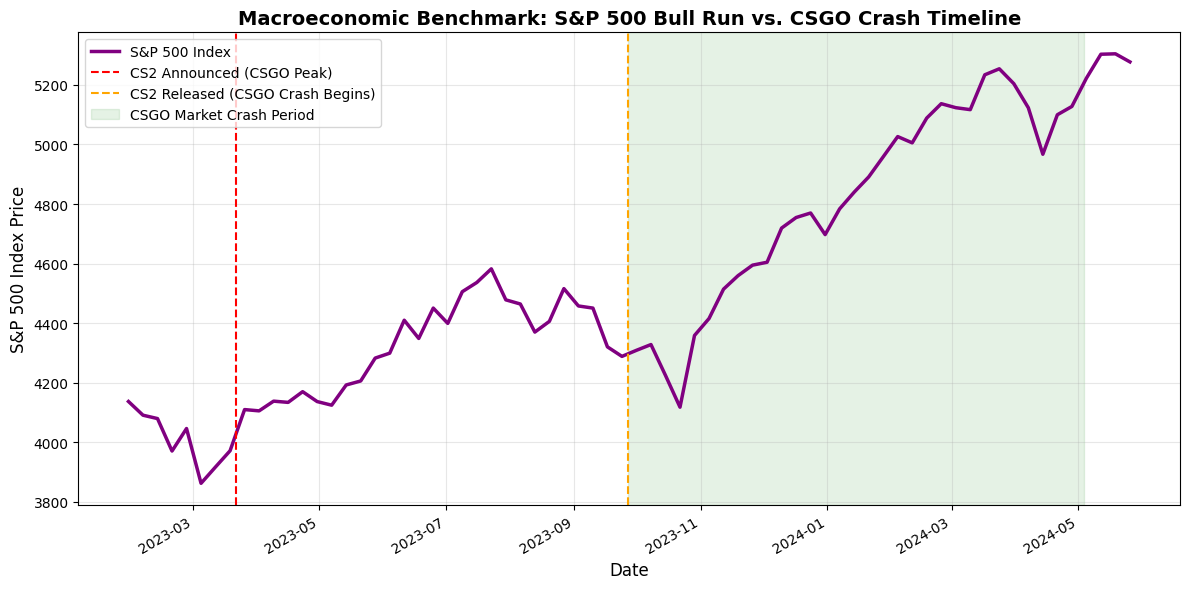

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Read the S&P 500 data
try:
    df_sp500 = pd.read_csv(r'D:\UIUC大学课程相关\课外活动经历记录\论文写作\S&P 500 Historical Data.csv')

    # Clean Data
    df_sp500['Price'] = df_sp500['Price'].astype(str).str.replace(',', '').astype(float)
    df_sp500['Date'] = pd.to_datetime(df_sp500['Date'])
    df_sp500 = df_sp500.sort_values('Date')

    # Filter for the relevant period: Jan 2023 to June 2024
    df_sp500_filtered = df_sp500[
        (df_sp500['Date'] >= '2023-01-01') &
        (df_sp500['Date'] <= '2024-06-01')
    ]

    plt.figure(figsize=(12, 6))

    # Plot S&P 500 trend
    plt.plot(
        df_sp500_filtered['Date'],
        df_sp500_filtered['Price'],
        color='purple',
        linewidth=2.5,
        label='S&P 500 Index'
    )

    # Add vertical lines for CS2 events
    plt.axvline(pd.to_datetime('2023-03-22'), color='red', linestyle='--',
                linewidth=1.5, label='CS2 Announced (CSGO Peak)')
    plt.axvline(pd.to_datetime('2023-09-27'), color='orange', linestyle='--',
                linewidth=1.5, label='CS2 Released (CSGO Crash Begins)')

    # Highlight the divergence period
    plt.axvspan(pd.to_datetime('2023-09-27'), pd.to_datetime('2024-05-04'),
                color='green', alpha=0.1, label='CSGO Market Crash Period')

    plt.title('Macroeconomic Benchmark: S&P 500 Bull Run vs. CSGO Crash Timeline',
              fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('S&P 500 Index Price', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')

    # Format x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.savefig('sp500_macro_trend.png', dpi=300)
    print("S&P 500 plot generated successfully.")

except Exception as e:
    print("Error:", e)

正在初始化数据管道，读取并清洗数据...
数据清洗完成，时间序列对齐完毕。开始渲染图表...


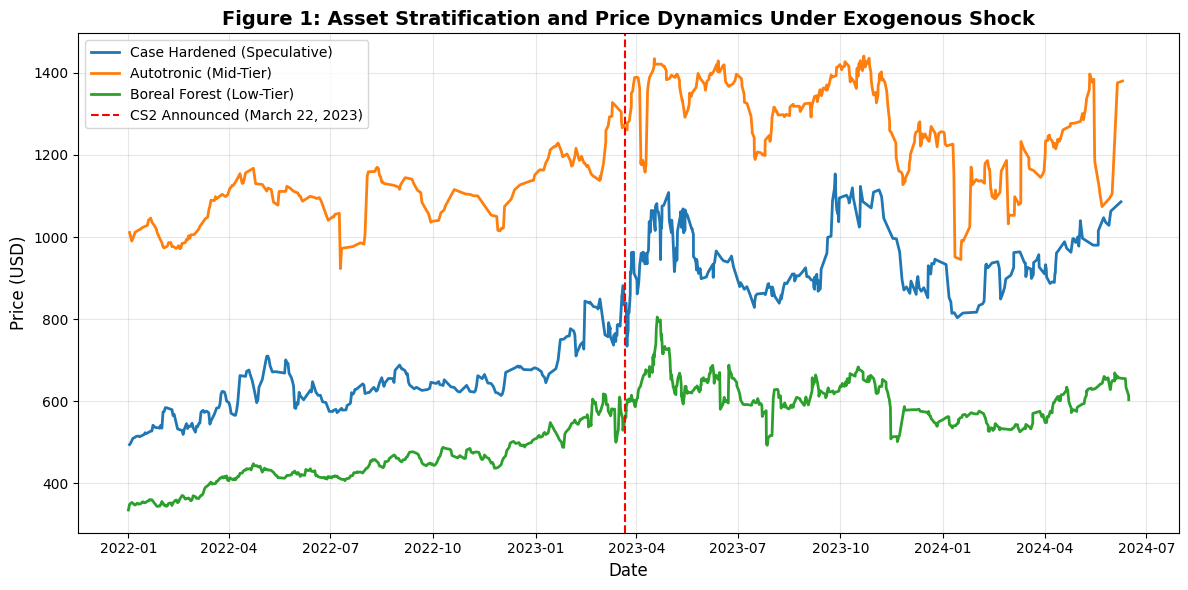

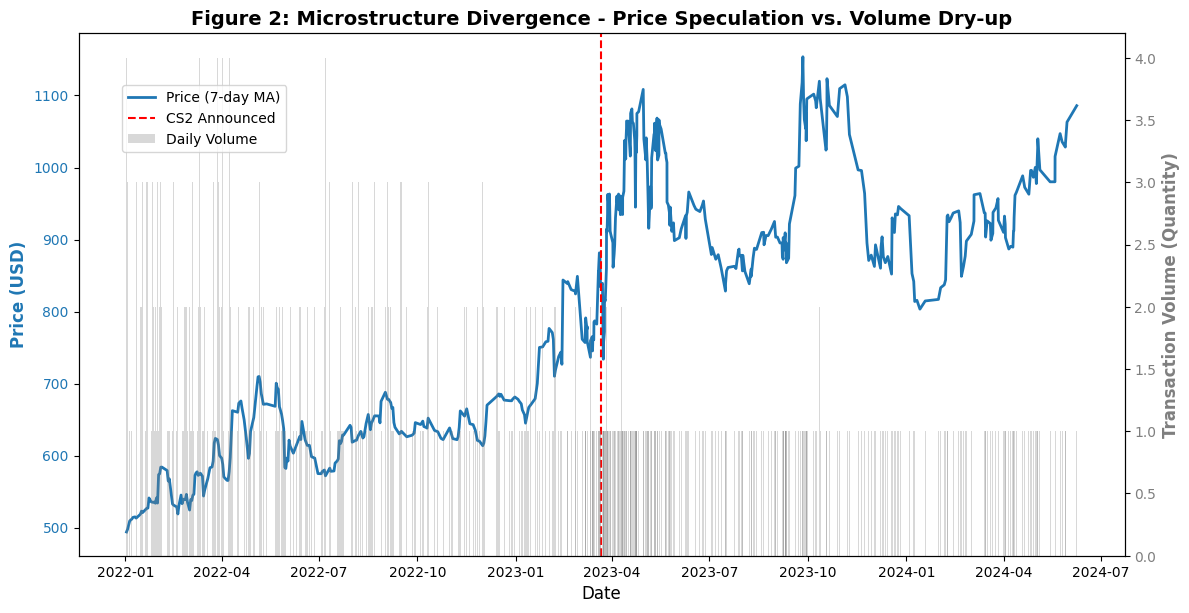

全栈渲染完毕！高清图表已输出到脚本所在目录。


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os  

DATA_DIR = r"D:\UIUC大学课程相关\课外活动经历记录\论文写作\Butterfly-Knife"

files = {
    'Case Hardened (Speculative)': '★%20Butterfly%20Knife%20%7C%20Case%20Hardened%20(Field-Tested).csv',
    'Autotronic (Mid-Tier)': '★%20Butterfly%20Knife%20%7C%20Autotronic%20(Field-Tested).csv',
    'Boreal Forest (Low-Tier)': '★%20Butterfly%20Knife%20%7C%20Boreal%20Forest%20(Field-Tested).csv'
}

dataframes = {}

print("正在初始化数据管道，读取并清洗数据...")


for name, filename in files.items():
    full_path = os.path.join(DATA_DIR, filename)
    try:
        df = pd.read_csv(full_path)
    except FileNotFoundError:
        print(f"❌ 严重错误：找不到数据文件。请检查路径是否正确：\n{full_path}")
        raise
    
    df['datetime'] = pd.to_datetime(df['unix timestamp'], unit='s')
    
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    
    df = df[df.index >= '2022-01-01']
    dataframes[name] = df

print("数据清洗完成，时间序列对齐完毕。开始渲染图表...")

# ==========================================
# 3. 绘制图表一：三把刀的泡沫破裂对比图
# ==========================================
plt.figure(figsize=(12, 6))

for name, df in dataframes.items():
    # Use 7-day MA Eliminate daily microscopic noise and highlight macro trends
    smoothed_price = df['price'].rolling(window=7, min_periods=1).mean()
    plt.plot(df.index, smoothed_price, label=name, linewidth=2)

# Point out Exogenous Shock
plt.axvline(pd.to_datetime('2023-03-22'), color='red', linestyle='--', linewidth=1.5, label='CS2 Announced (March 22, 2023)')

plt.title('Figure 1: Asset Stratification and Price Dynamics Under Exogenous Shock', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_1_Price_Comparison.png', dpi=300) 
plt.show() 

# ==========================================
# 4. 绘制图表二：投机资产的微观结构与流动性枯竭
# ==========================================
df_ch = dataframes['Case Hardened (Speculative)']

fig, ax1 = plt.subplots(figsize=(12, 6))

# left Y axis: (Price Action)
color_price = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Price (USD)', color=color_price, fontsize=12, weight='bold')
ax1.plot(df_ch.index, df_ch['price'].rolling(7, min_periods=1).mean(), color=color_price, linewidth=2, label='Price (7-day MA)')
ax1.tick_params(axis='y', labelcolor=color_price)
ax1.axvline(pd.to_datetime('2023-03-22'), color='red', linestyle='--', label='CS2 Announced')

# Right Y axis: (Market Depth / Volume)
ax2 = ax1.twinx()  
color_vol = 'tab:gray'
ax2.set_ylabel('Transaction Volume (Quantity)', color=color_vol, fontsize=12, weight='bold')  
ax2.bar(df_ch.index, df_ch['quantity'], color=color_vol, alpha=0.3, label='Daily Volume')
ax2.tick_params(axis='y', labelcolor=color_vol)

fig.tight_layout()  
plt.title('Figure 2: Microstructure Divergence - Price Speculation vs. Volume Dry-up', fontsize=14, fontweight='bold')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9), frameon=True)

plt.savefig('Figure_2_Liquidity_Crash.png', dpi=300, bbox_inches='tight')
plt.show()

print("全栈渲染完毕！高清图表已输出到脚本所在目录。")

开始计算 Amihud 非流动性指标并进行时间序列合并...


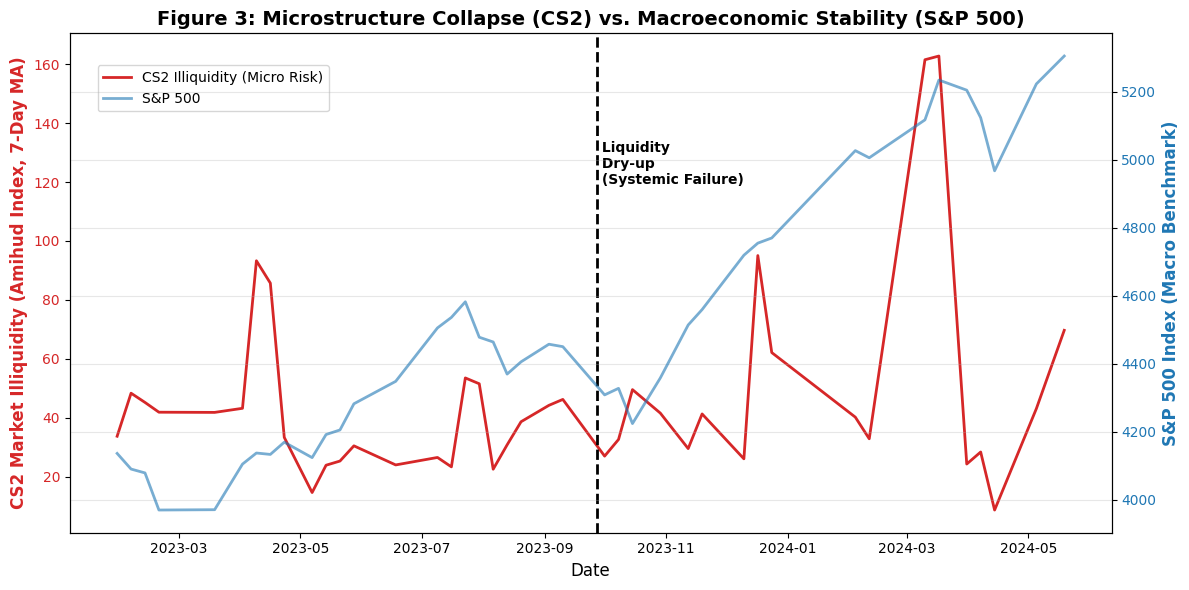

图表 3 生成完毕！


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("开始计算 Amihud 非流动性指标并进行时间序列合并...")

# ==========================================
# 1. Feature Engineering
# ==========================================
# Choose Autotronic
df_cs = dataframes['Autotronic (Mid-Tier)'].copy()

df_cs.index = df_cs.index.normalize()

df_cs = df_cs.groupby(df_cs.index).agg({'price': 'mean', 'quantity': 'sum'})

# ==========================================
# 2. 计算 Amihud
# ==========================================
# Daily Return
df_cs['Daily_Return'] = df_cs['price'].pct_change()
# Dollar Volume
df_cs['Dollar_Volume'] = df_cs['price'] * df_cs['quantity']

df_cs['Amihud'] = (df_cs['Daily_Return'].abs() / df_cs['Dollar_Volume']) * 1e6

# Smooth the data using a 7-day moving average
df_cs['Amihud_MA7'] = df_cs['Amihud'].rolling(window=7, min_periods=1).mean()

# ==========================================
# 3. Data Merging
# ==========================================
df_macro = df_sp500_filtered.copy()
df_macro.set_index('Date', inplace=True)
df_macro.index = df_macro.index.normalize()

# 内连接合并 (Inner Join)：只保留大盘和 CS 市场同时开盘、都有数据的交易日
df_merged = pd.merge(df_cs, df_macro[['Price']], left_index=True, right_index=True, how='inner')
df_merged.rename(columns={'Price': 'SP500_Price'}, inplace=True)

# ==========================================
# 4. 绘制双 Y 轴图表 (Data Visualization)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# 左侧 Y 轴：CS2 市场的 Amihud 流动性枯竭指数 
color_amihud = '#d62728' 
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('CS2 Market Illiquidity (Amihud Index, 7-Day MA)', color=color_amihud, fontsize=12, fontweight='bold')
ax1.plot(df_merged.index, df_merged['Amihud_MA7'], color=color_amihud, linewidth=2, label='CS2 Illiquidity (Micro Risk)')
ax1.tick_params(axis='y', labelcolor=color_amihud)

# 右侧 Y 轴：S&P 500 宏观大盘指数 
ax2 = ax1.twinx()
color_sp = '#1f77b4' 
ax2.set_ylabel('S&P 500 Index (Macro Benchmark)', color=color_sp, fontsize=12, fontweight='bold')
ax2.plot(df_merged.index, df_merged['SP500_Price'], color=color_sp, alpha=0.6, linewidth=2, label='S&P 500')
ax2.tick_params(axis='y', labelcolor=color_sp)

crash_date = pd.to_datetime('2023-09-27')
ax1.axvline(crash_date, color='black', linestyle='--', linewidth=2)

ax1.text(crash_date, ax1.get_ylim()[1]*0.7, ' Liquidity\n Dry-up\n (Systemic Failure)', color='black', fontweight='bold')

plt.title('Figure 3: Microstructure Collapse (CS2) vs. Macroeconomic Stability (S&P 500)', fontsize=14, fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(0.02, 0.95), frameon=True)

plt.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig('Figure_3_Amihud_vs_SP500.png', dpi=300)
plt.show()

print("图表 3 生成完毕！")

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("开始构建多元 OLS 回归模型...")

models_results = {}

# 宏观基准：计算标普 500 的日收益率
df_macro = df_sp500_filtered.copy()
df_macro.set_index('Date', inplace=True)
df_macro.index = df_macro.index.normalize()
df_macro['SP500_Return'] = df_macro['Price'].pct_change()

# 遍历之前清洗好的三个资产字典 dataframes
for asset_name, df in dataframes.items():
    df_reg = df.copy()
    df_reg.index = df_reg.index.normalize()
    
    # 1. 聚合每日数据
    df_reg = df_reg.groupby(df_reg.index).agg({'price': 'mean', 'quantity': 'sum'})
    
    # 2. 构建核心因变量 (Y) 和自变量 (X)
    df_reg['Daily_Return'] = df_reg['price'].pct_change()
    df_reg['Abs_Return'] = df_reg['Daily_Return'].abs() # Y: 波动率/踩踏程度
    
    df_reg['Dollar_Volume'] = df_reg['price'] * df_reg['quantity']
    # 计算 Amihud 
    df_reg['Amihud'] = (df_reg['Abs_Return'] / (df_reg['Dollar_Volume'] + 1e-8)) * 1e6
    
    # 3. 高阶特征工程
    # 取 Amihud 的对数以消除极端偏态分布 (Log transformation)
    df_reg['Log_Amihud'] = np.log(df_reg['Amihud'] + 1)
    # 取前一日的流动性，防止自相关和前视偏差 (Lagged variable)
    df_reg['Lag_Log_Amihud'] = df_reg['Log_Amihud'].shift(1)
    
    # 4. 设定外生冲击虚拟变量 (Dummy Variable: Shock)
    # 假设 2023-09-27 为 CS2 发布崩盘日
    shock_date = pd.to_datetime('2023-09-27')
    df_reg['Shock_Dummy'] = (df_reg.index >= shock_date).astype(int)
    
    # 5. 合并宏观控制变量
    df_reg = pd.merge(df_reg, df_macro[['SP500_Return']], left_index=True, right_index=True, how='inner')
    
    # 清洗掉所有 NaN 值 (因计算收益率和 Lag 产生的缺失值)
    df_reg.dropna(inplace=True)
    
    # ==========================================
    # 执行 OLS 回归 (带有交互项)
    # 公式：Abs_Return ~ Lag_Log_Amihud + Shock_Dummy + (Lag_Log_Amihud * Shock_Dummy) + SP500_Return
    # ==========================================
    formula = 'Abs_Return ~ Lag_Log_Amihud * Shock_Dummy + SP500_Return'
    model = smf.ols(formula=formula, data=df_reg).fit(cov_type='HC1') # HC1：使用稳健标准误 (Robust Standard Errors)
    
    models_results[asset_name] = model

# ==========================================
# 打印回归汇总表
# ==========================================
from statsmodels.iolib.summary2 import summary_col

# 将三个模型并排展示
results_table = summary_col([models_results['Boreal Forest (Low-Tier)'], 
                             models_results['Autotronic (Mid-Tier)'], 
                             models_results['Case Hardened (Speculative)']],
                            model_names=['Model 1: Low-Tier (Retail)', 
                                         'Model 2: Mid-Tier (Baseline)', 
                                         'Model 3: High-Tier (Speculative)'],
                            stars=True, 
                            regressor_order=['Intercept', 'Lag_Log_Amihud', 'Shock_Dummy', 'Lag_Log_Amihud:Shock_Dummy', 'SP500_Return'],
                            info_dict={'N': lambda x: f"{int(x.nobs)}", 'R2': lambda x: f"{x.rsquared:.4f}"})

print("\n" + "="*80)
print("Table 1: OLS Regression Results (Dependent Variable: Absolute Daily Return)")
print("="*80)
print(results_table)

开始构建多元 OLS 回归模型...

Table 1: OLS Regression Results (Dependent Variable: Absolute Daily Return)

                           Model 1: Low-Tier (Retail) Model 2: Mid-Tier (Baseline) Model 3: High-Tier (Speculative)
-------------------------------------------------------------------------------------------------------------------
Intercept                  0.0651***                  0.0090                       0.0086                          
                           (0.0129)                   (0.0258)                     (0.1170)                        
Lag_Log_Amihud             -0.0031                    0.0142                       0.0270                          
                           (0.0034)                   (0.0089)                     (0.0264)                        
Shock_Dummy                -0.0191                    -0.0197                      -0.0214                         
                           (0.0309)                   (0.0304)                     (0.1337)